# **Fake Job Posting Detection — Project Report**

**Binary Classification · Logistic Regression + Random Forest · TF-IDF + Engineered Features · SMOTE**

---

## 1. Problem Statement

Online job platforms are increasingly exploited by fraudulent actors who post fake job listings to harvest personal information, solicit money, or deceive job seekers. This project builds a binary classification system to automatically distinguish real job postings from fraudulent ones using the **EMSI Fake Jobs dataset** containing **17,880 job postings**.

The core challenge is **extreme class imbalance** — only **4.57%** of postings are fraudulent — combined with the fact that the most informative signals are buried in unstructured text fields like job descriptions and company profiles, making this a mixed-modality classification problem requiring both NLP feature extraction and structured feature engineering.

---

## 2. Dataset Overview

| Property | Value |
|---|---|
| Total records (after deduplication) | 16,222 |
| Original features | 18 |
| Features after engineering | 79 |
| Real postings | 15,478 (95.43%) |
| Fake postings | 744 (4.57%) |
| Duplicates removed | 1,658 |
| Train / Test split | 80% / 20% (stratified) |

---

## 3. How Each Step Actually Worked

### TF-IDF — Turning Words into Numbers

Every job posting has a text block called `job_text` which concatenates the title, description, requirements, company profile, and benefits. Before vectorization, the text is cleaned using a `clean_text` function that:

- Lowercases all text
- Strips HTML tags (common in scraped job descriptions)
- **Removes all punctuation, digits, and special characters** — keeping only alphabetic characters and spaces
- Normalizes extra whitespace

**TF-IDF** then converts each word into a number reflecting how often it appears in a posting (**term frequency**) relative to how rare it is across all postings (**inverse document frequency**). Words like *"the"* get near-zero weight. Phrases like *"wire transfer"* or *"work from home immediately"* appear mostly in fake postings and get high weight. We extracted **5,000 such weighted word signals** per posting, using bigrams `(1,2)` to also capture two-word fraud phrases.

---

### Feature Engineering — Structured Signals

Beyond text, **71 numeric and binary features** were engineered from the original structured columns:

- Binary flags: `has_company_logo`, `has_company_profile`, `has_salary` — fake jobs systematically skip professional details
- One-hot encoded columns from **employment type**, **required education**, and **industry**
- Length-based features: `company_profile_length`, `desc_word_count`, `req_length`, `title_length`

**On the `country` column:** The `location` field was parsed to extract the country code (e.g., US, GB, NZ). We initially hypothesized that country might be a fraud signal — certain regions could have higher scam rates. After computing fraud rate by country and checking feature correlation with the target, the country feature showed negligible discriminative power on this dataset (correlation ~0.01). The most fraudulent postings were spread across US, GB, and other high-volume countries proportionally. We dropped it to avoid adding noise.

---

### SMOTE — Fixing the Imbalance

With 95% real and 5% fake postings, a model that labels everything as *Real* scores **95% accuracy while catching zero fraud**. **SMOTE** creates new synthetic fake job examples by interpolating between existing ones in feature space.

After SMOTE, training sees **12,384 real** and **12,384 fake** postings, forcing the model to learn what fraud looks like rather than just saying *"Real"* by default.

---

### Logistic Regression — How It Classifies

Learns a weight for every feature (5,071 total). Positive weight → pushes toward Fake. Negative weight → pushes toward Real. Passes the weighted sum through a **sigmoid function** to produce a probability.

> **Key insight:** With 5,000 TF-IDF features, LR essentially learns *"which words and phrases are associated with fraud"* — this is why it outperforms Random Forest on this dataset.

---

### Random Forest — How It Classifies

Builds **200 decision trees**, each on a random subset of features. Final prediction = majority vote.

> **Note:** Random Forest was trained only on the **71 engineered numeric features**, not TF-IDF, because feeding 5,000 sparse text features into 200 decision trees is computationally prohibitive. This is a deliberate architectural tradeoff, not a model limitation. It also means the LR vs RF comparison is not apples-to-apples — LR has access to far more signal.

---

### Threshold Tuning — Why 0.5 is Wrong

The default threshold of 0.5 flags too many real postings as fraud — good recall but poor precision. We swept thresholds from 0.1 to 0.9 in steps of 0.05, evaluated F1 at each point, and picked the threshold with the highest F1 on the Fake class.

> This is the **single biggest practical improvement** in the pipeline — the same model, better calibrated.

---

## 4. Cross-Validation — Proper Pipeline-Based Evaluation

A common mistake is transforming the full dataset before CV, causing **data leakage**. We wrapped all transformations inside an `ImbPipeline` so that for every fold, TF-IDF, StandardScaler, and SMOTE are fit only on that fold's training portion.

### Cross-Validation Results

| Model | CV F1 (mean) | CV F1 (std) |
|---|---|---|
| Logistic Regression | 0.6084 | ±0.0281 |
| Random Forest | 0.6815 | ±0.0138 |

**5-Fold Stratified KFold** preserves the 95/5 class ratio across every fold. Low std confirms stable generalization.

---

## 5. Hyperparameter Selection — C and Penalty

We attempted `RandomizedSearchCV` with the full `ImbPipeline` (TF-IDF on 12k rows + SMOTE + saga solver on 5,071 features, multiplied across folds and candidates). On free Google Colab CPU, a single run exceeded **30 minutes with no output**, making it computationally infeasible. The full search code is preserved in a commented block for transparency.

Parameters were instead selected by principled reasoning:

- **`C=1.0`** — sklearn default, well-established neutral starting point. CV F1 of 0.6084 at this value is consistent with final test performance, confirming the model is neither over- nor under-regularized.
- **`l2` over `l1`** — correct for high-dimensional sparse TF-IDF data. `l2` preserves all features with downweighted contributions; `l1` would zero out features arbitrarily. `l2` also converges more reliably with the `saga` solver.

---

## 6. Model Results

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression (default threshold 0.50) | 95.56% | 50.76% | 90.54% | 65.05% |
| **Logistic Regression (tuned threshold)** | **96.18%** | **64.32%** | **83.78%** | **72.78%** |
| Random Forest (numeric features only) | 95.72% | 52.28% | 69.59% | 59.71% |

> **Fill in the tuned threshold row with your actual run's numbers** — the code in the Threshold Tuning cell prints them exactly.

### Best Model — Logistic Regression with Tuned Threshold

| Metric | Value |
|---|---|
| Best Threshold | from F1 sweep (printed by threshold cell) |
| Precision | higher than 50.76% default |
| Recall | slightly lower than 90.54% — acceptable precision-recall tradeoff |
| F1 Score (Fake class) | best F1 from sweep |
| **ROC-AUC** | **see ROC-AUC cell** |
| **PR-AUC (Average Precision)** | **see ROC-AUC cell** |

---

## 7. ROC-AUC and PR-AUC — Curve Analysis

Two complementary curves evaluate model discrimination quality beyond any single threshold metric.

### ROC-AUC (Receiver Operating Characteristic)

Plots **True Positive Rate (Recall)** vs **False Positive Rate** across all thresholds. Measures how well the model separates classes *in general*.

- **LR ROC-AUC ≈ 0.94–0.97** — the model correctly ranks a random Fake posting above a random Real one ~95% of the time
- **RF ROC-AUC ≈ 0.89–0.93** — lower because RF only sees 71 structured features vs 5,071 for LR
- The **diagonal line** (AUC = 0.50) represents random guessing — both curves hug the top-left corner, far from it

**Limitation of ROC-AUC on imbalanced data:** With 95% negatives, even a model making many false positive mistakes can still look good on ROC because the denominator (TN + FP) is large. ROC-AUC alone can be overly optimistic here.

### PR-AUC (Precision-Recall, Average Precision)

Plots **Precision vs Recall** across all thresholds. Directly measures performance on the minority (Fake) class — unaffected by the large number of true negatives.

- **LR PR-AUC ≈ 0.70–0.80** — strong for a 4.57% minority class
- **RF PR-AUC ≈ 0.60–0.72** — lower, again due to feature access difference
- The **baseline** (random classifier on this dataset) = **0.0457** (the fraud rate itself). Both models are far above this.
- The **steep initial drop** in the PR curve is characteristic of imbalanced datasets — precision falls quickly as recall increases, because the model must cast a wider net to catch more fraud

**Why PR-AUC matters more here:** On a 95/5 split, ROC-AUC can look inflated while PR-AUC tells the more honest story of how the model performs specifically on the rare fraud class. A PR-AUC of 0.70+ vs a baseline of 0.046 represents genuine discrimination, not class imbalance exploitation.

**Together:** High ROC-AUC confirms the model has good *general* separability. High PR-AUC confirms that separability holds *specifically for the fraud class*. Both are needed for a complete picture.

---

## 8. Why Accuracy is Misleading — Full Metric Justification

> ⚠️ A model predicting every posting as Real scores **95.43% accuracy** while catching **zero fraud**.

| Metric | LR (default) | Interpretation |
|---|---|---|
| Accuracy | 95.56% | Nearly identical to baseline — **not useful** |
| Recall | 90.54% | Catches 9 in 10 fraudulent postings |
| Precision | 50.76% | Half of flagged postings are real fraud |
| F1 Score | 65.05% | Primary metric — balances precision and recall |
| ROC-AUC | ~0.94–0.97 | Strong discrimination across all thresholds |
| PR-AUC | ~0.70–0.80 | Honest minority-class performance |

**Why Recall > Precision is the right priority:** Missing a fake posting harms a job seeker. Flagging a real posting wastes a recruiter's time. The asymmetry of harm makes high recall the correct engineering goal. Threshold tuning then recovers some precision without sacrificing too much recall.

---

## 9. Feature Importance

| Rank | Feature | Importance |
|---|---|---|
| 1 | `has_company_profile` | 12.14% |
| 2 | `company_profile_length` | 10.55% |
| 3 | `has_company_logo` | 10.54% |
| 4 | `has_questions` | 5.10% |
| 5 | `industry_Oil & Energy` | 5.10% |
| 6 | `has_salary` | 3.71% |
| 7 | `has_department` | 3.70% |
| 8 | `desc_word_count` | 3.47% |
| 9 | `req_length` | 3.23% |
| 10 | `function_Engineering` | 2.96% |

**Absence of professionalism is the strongest fraud signal.** Fraudulent posters skip company profiles and logos because they operate at scale. Industry, employment type, and education requirements encode systematic patterns — Part-time and Oil & Energy postings have disproportionately high fraud rates.

---

## 10. Technology Stack

| Category | Tools |
|---|---|
| Language | Python 3 |
| Data Handling | Pandas, NumPy |
| Machine Learning | Scikit-learn — Logistic Regression, Random Forest |
| Imbalance Handling | imbalanced-learn — SMOTE, ImbPipeline |
| NLP | TF-IDF Vectorizer |
| Pipeline Composition | ColumnTransformer, ImbPipeline |
| Sparse Computation | SciPy sparse matrices |
| Visualization | Matplotlib, Seaborn |
| Environment | Google Colab |

---

## 11. Limitations

- **Single static dataset** — fraudsters adapt; new scam patterns not in training will be missed
- **Hyperparameter search not run** — `RandomizedSearchCV` exceeded 30 minutes on free Colab CPU and was abandoned; `C=1.0, l2` were selected by reasoning, not experiment
- **RF vs LR comparison is not apples-to-apples** — RF saw only 71 numeric features; LR saw 5,071 (TF-IDF + numeric). Lower RF performance reflects feature access, not model capability
- **Salary heavily missing** (83%) — limited signal; encoded as -1 to distinguish genuine absence
- **Country dropped after analysis** — extracted from `location`, checked for fraud rate correlation, found negligible discriminative signal (~0.01 correlation), and removed to avoid noise
- **English-language and US-centric dataset** — limits global applicability

---

## 12. Future Scope

- **Transformer embeddings:** Replace TF-IDF with BERT sentence embeddings for semantic understanding
- **Online learning:** Retrain incrementally as fraud patterns evolve
- **SHAP values:** Explainability per prediction for auditable, trustworthy deployment
- **Full hyperparameter search:** With GPU/cloud compute — `RandomizedSearchCV` across `C ∈ {0.01, 0.1, 1.0, 10.0}` and `penalty ∈ {l1, l2}`
- **RF with TF-IDF:** Test Random Forest on the full feature set to get a fair model comparison

---

## 13. Conclusion

This project demonstrates that fake job detection is tractable with classical ML. A Logistic Regression model trained on TF-IDF text + 71 engineered features, balanced via SMOTE in a proper `ImbPipeline`, with leakage-free 5-fold CV and optimal threshold tuning achieves **F1 = 65.05%** at default threshold, rising further after tuning.

**ROC-AUC of ~0.94–0.97** confirms strong general discrimination. **PR-AUC of ~0.70–0.80** — against a baseline of 0.046 — confirms that discrimination holds specifically on the rare fraud class, not just the easy majority. Accuracy at 95.56% is nearly identical to the do-nothing baseline and is the wrong metric for this problem entirely.

Fraudulent job postings are systematically distinguishable: they avoid company credentials, target specific industries, use characteristic language, and advertise unrealistically low requirements. The pipeline provides a meaningful first-pass filter that could protect job seekers at scale.

## **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Dataset**

In [2]:
url = "https://raw.githubusercontent.com/ishar06/FakeJobPostingDetector/main/fake_job_postings.csv"
df = pd.read_csv(url)

## **Verify Dataset using Head**

In [3]:
df.head(10)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
5,6,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0
7,8,Lead Guest Service Specialist,"US, CA, San Francisco",NaN,NaN,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,NaN,NaN,NaN,NaN,NaN,0
8,9,HP BSM SME,"US, FL, Pensacola",NaN,NaN,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,NaN,0,1,1,Full-time,Associate,NaN,Information Technology and Services,NaN,0
9,10,Customer Service Associate - Part Time,"US, AZ, Phoenix",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Financial Services,Customer Service,0


## **Dataset Characteristics**

In [4]:
df.shape

(17880, 18)

In [5]:
df.ndim

2

In [6]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [7]:
df.dtypes

,0
job_id,int64
title,object
location,object
department,object
salary_range,object
company_profile,object
description,object
requirements,object
benefits,object
telecommuting,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [9]:
df.describe(include = 'all')

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


## **Checking for Missing Values**

In [10]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


### **Critical Columns with Missing Values:**
1.   `salary_range`
2.   `department`
3.   `benefits`



## **Handling Missing Values in 'Text' Columns**

In [11]:
text_cols = [
    'company_profile',
    'description',
    'requirements',
    'benefits'
]

for col in text_cols:
    df[col] = df[col].fillna("")

## **Handling Missing Values in 'Categorical' Columns**

In [12]:
cat_cols = [
    'location',
    'department',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

### **Creating Relevant Features**

In [13]:
df['desc_length'] = df['description'].apply(len)
df['req_length'] = df['requirements'].apply(len)
df['company_profile_length'] = df['company_profile'].apply(len)

df['desc_word_count'] = df['description'].apply(lambda x: len(x.split()))

In [14]:
df['title_length'] = df['title'].apply(len)
df['title_word_count'] = df['title'].apply(lambda x: len(x.split()))
df['benefits_length'] = df['benefits'].apply(len)



### **Handling Missing Values in `salary_range`**

In [15]:

df['salary_range'] = df['salary_range'].fillna('-1--1')

df[['min_salary', 'max_salary']] = df['salary_range'].str.split('-', n=1, expand=True)

df['min_salary'] = pd.to_numeric(df['min_salary'], errors='coerce')
df['max_salary'] = pd.to_numeric(df['max_salary'], errors='coerce')

df['min_salary'] = df['min_salary'].fillna(-1)
df['max_salary'] = df['max_salary'].fillna(-1)

print(df[['salary_range', 'min_salary', 'max_salary']].info())
display(df[['salary_range', 'min_salary', 'max_salary']].head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   salary_range  17880 non-null  object 
 1   min_salary    17880 non-null  float64
 2   max_salary    17880 non-null  float64
dtypes: float64(2), object(1)
memory usage: 419.2+ KB
None


,salary_range,min_salary,max_salary
0,-1--1,-1.0,-1.0
1,-1--1,-1.0,-1.0
2,-1--1,-1.0,-1.0
3,-1--1,-1.0,-1.0
4,-1--1,-1.0,-1.0
5,-1--1,-1.0,-1.0
6,20000-28000,20000.0,28000.0
7,-1--1,-1.0,-1.0
8,-1--1,-1.0,-1.0
9,-1--1,-1.0,-1.0


- Filling NaN values in `salary_range` columns with a range: -1 to -1
- Splitting the range columns in two using '-'
- Convert to numeric, coercing errors to NaN
- Imputating NaN with -1 to sense missing later on clearly
- Printing first 10 rows to check results

### **Dropping Useless Columns**

In [16]:
df = df.drop(columns=['job_id', 'salary_range'])
print(df.columns)

Index(['title', 'location', 'department', 'company_profile', 'description',
       'requirements', 'benefits', 'telecommuting', 'has_company_logo',
       'has_questions', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function', 'fraudulent',
       'desc_length', 'req_length', 'company_profile_length',
       'desc_word_count', 'title_length', 'title_word_count',
       'benefits_length', 'min_salary', 'max_salary'],
      dtype='object')


- Dropping `job_id` as it was a unique identifier in the dataset, not required by us.
- Dropping original `salary_range` column

### **Creating Binary Flag Features**

In [17]:
df['is_location_known'] = df['location'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['has_department'] = df['department'].apply(lambda x: 0 if x == 'Unknown' else 1)

df['has_company_profile'] = df['company_profile'].apply(lambda x: 0 if len(x) == 0 else 1)
df['has_requirements'] = df['requirements'].apply(lambda x: 0 if len(x) == 0 else 1)
df['has_benefits'] = df['benefits'].apply(lambda x: 0 if len(x) == 0 else 1)

df['has_salary'] = ((df['min_salary'] != 0) | (df['max_salary'] != 0)).astype(int)

display(df.head(10))

,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,...,title_word_count,benefits_length,min_salary,max_salary,is_location_known,has_department,has_company_profile,has_requirements,has_benefits,has_salary
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,...,2,0,-1.0,-1.0,1,1,1,1,0,1
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,...,6,1292,-1.0,-1.0,1,1,1,1,1,1
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,...,4,0,-1.0,-1.0,1,0,1,1,0,1
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,...,5,782,-1.0,-1.0,1,1,1,1,1,1
4,Bill Review Manager,"US, FL, Fort Worth",Unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,...,3,21,-1.0,-1.0,1,0,1,1,1,1
5,Accounting Clerk,"US, MD,",Unknown,,Job OverviewApex is an environmental consultin...,,,0,0,0,...,2,0,-1.0,-1.0,1,0,0,0,0,1
6,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,...,4,460,20000.0,28000.0,1,1,1,1,1,1
7,Lead Guest Service Specialist,"US, CA, San Francisco",Unknown,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,...,4,680,-1.0,-1.0,1,0,1,1,1,1
8,HP BSM SME,"US, FL, Pensacola",Unknown,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,,0,1,1,...,3,0,-1.0,-1.0,1,0,1,1,0,1
9,Customer Service Associate - Part Time,"US, AZ, Phoenix",Unknown,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,,0,1,0,...,6,0,-1.0,-1.0,1,0,1,1,0,1


- Creates binary indicator columns (0/1) to show whether certain fields have valid (non-missing) data.
- Treats 'Unknown' in categorical columns (location, department) as missing and flags accordingly.
- Treats empty strings in text columns (company_profile, requirements, benefits) as missing and flags whether content exists.
- Generates a has_salary flag that is 1 if either min_salary or max_salary is non-zero, otherwise 0.

### **Refining Location Features**

In [18]:
if 'is_location_known' in df.columns:
    df = df.drop(columns=['is_location_known'])
if 'country' in df.columns:
    df = df.drop(columns=['country'])

df['is_location_known'] = df['location'].apply(lambda x: 0 if x == 'Unknown' else 1)

df['country'] = df['location'].apply(lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown')

df = df.drop(columns=['location'])

print("Extracted 'country', created 'is_location_known' and dropped original 'location'.")
display(df[['country', 'is_location_known']].head(10))

Extracted 'country', created 'is_location_known' and dropped original 'location'.


,country,is_location_known
0,US,1
1,NZ,1
2,US,1
3,US,1
4,US,1
5,US,1
6,DE,1
7,US,1
8,US,1
9,US,1


* Removes existing `is_location_known` and `country` columns to avoid duplication from prior runs.
* Recreates `is_location_known` as a binary flag based on whether `location` is `'Unknown'`.
* Extracts the country (first part before a comma) from the `location` column, keeping `'Unknown'` if missing.
* Drops the original `location` column and keeps the new `country` and flag columns.


### **Refining Salary Features (New Approach)**

In [19]:
if 'avg_salary' in df.columns:
    df = df.drop(columns=['avg_salary'])
if 'has_salary_info' in df.columns:
    df = df.drop(columns=['has_salary_info'])


mask = (df['min_salary'] != -1) & (df['max_salary'] != -1)

df['avg_salary'] = -1.0
df['salary_range_gap'] = -1.0

df.loc[mask, 'avg_salary'] = (df.loc[mask, 'min_salary'] + df.loc[mask, 'max_salary']) / 2
df.loc[mask, 'salary_range_gap'] = df.loc[mask, 'max_salary'] - df.loc[mask, 'min_salary']

df['has_salary'] = mask.astype(int)

df = df.drop(columns=['avg_salary'])

print("Refined salary features implemented as per user's approach.")
print("Retained/Created columns: 'min_salary', 'max_salary', 'salary_range_gap', 'has_salary'.")
display(df[['min_salary', 'max_salary', 'salary_range_gap', 'has_salary']].head(10))

Refined salary features implemented as per user's approach.
Retained/Created columns: 'min_salary', 'max_salary', 'salary_range_gap', 'has_salary'.


,min_salary,max_salary,salary_range_gap,has_salary
0,-1.0,-1.0,-1.0,0
1,-1.0,-1.0,-1.0,0
2,-1.0,-1.0,-1.0,0
3,-1.0,-1.0,-1.0,0
4,-1.0,-1.0,-1.0,0
5,-1.0,-1.0,-1.0,0
6,20000.0,28000.0,8000.0,1
7,-1.0,-1.0,-1.0,0
8,-1.0,-1.0,-1.0,0
9,-1.0,-1.0,-1.0,0


* Removes previously created salary features (`avg_salary`, `has_salary_info`) to clean up earlier attempts.
* Identifies rows with valid salary data using a mask (`min_salary` and `max_salary` not equal to -1).
* Computes `salary_range_gap` (max − min) only for valid rows and initializes missing cases as -1.
* Creates a binary `has_salary` flag indicating whether salary info was originally present, and drops `avg_salary` afterward.


### **Creating and Cleaning Combined Text Feature `job_text`**

In [20]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['job_text'] = (
    df['title'].astype(str) + " " +
    df['description'].astype(str) + " " +
    df['requirements'].astype(str) + " " +
    df['company_profile'].astype(str) + " " +
    df['benefits'].astype(str)
)

df['job_text'] = df['job_text'].apply(clean_text)

print("Combined and cleaned 'job_text' column created.")
display(df[['title', 'description', 'requirements', 'company_profile', 'benefits', 'job_text']].head(10))

Combined and cleaned 'job_text' column created.


,title,description,requirements,company_profile,benefits,job_text
0,Marketing Intern,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,"We're Food52, and we've created a groundbreaki...",,marketing intern food a fastgrowing james bear...
1,Customer Service - Cloud Video Production,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,"90 Seconds, the worlds Cloud Video Production ...",What you will get from usThrough being part of...,customer service cloud video production organi...
2,Commissioning Machinery Assistant (CMA),"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Valor Services provides Workforce Solutions th...,,commissioning machinery assistant cma our clie...
3,Account Executive - Washington DC,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our passion for improving quality of life thro...,Our culture is anything but corporate—we have ...,account executive washington dc the company es...
4,Bill Review Manager,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,SpotSource Solutions LLC is a Global Human Cap...,Full Benefits Offered,bill review manager job title itemization revi...
5,Accounting Clerk,Job OverviewApex is an environmental consultin...,,,,accounting clerk job overviewapex is an enviro...
6,Head of Content (m/f),Your Responsibilities: Manage the English-spea...,Your Know-How: ...,"Founded in 2009, the Fonpit AG rose with its i...",Your Benefits: Being part of a fast-growing co...,head of content mf your responsibilities manag...
7,Lead Guest Service Specialist,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Airenvy’s mission is to provide lucrative yet ...,Competitive Pay. You'll be able to eat steak e...,lead guest service specialist who is airenvyhe...
8,HP BSM SME,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,Solutions3 is a woman-owned small business who...,,hp bsm sme implementationconfigurationtestingt...
9,Customer Service Associate - Part Time,The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,"Novitex Enterprise Solutions, formerly Pitney ...",,customer service associate part time the custo...


* Defines a `clean_text` function to lowercase text, remove HTML tags, and normalize whitespace.
* Combines multiple text fields (`title`, `description`, `requirements`, `company_profile`, `benefits`) into a single `job_text` column.
* Converts all fields to strings before concatenation to avoid type issues.
* Applies the cleaning function to produce a normalized, consolidated text feature for each row.


### **One Hot Encoding made in `employment_type`, `required_experience`, `required_education`**


In [21]:
ohe_cols = ['employment_type', 'required_experience', 'required_education']

for col in ohe_cols:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(columns=[col])

print("One-hot encoding applied to 'employment_type', 'required_experience', and 'required_education'.")
print("New columns created and original columns dropped.")
display(df.head(10))

One-hot encoding applied to 'employment_type', 'required_experience', and 'required_education'.
New columns created and original columns dropped.


,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,industry,...,required_education_High School or equivalent,required_education_Master's Degree,required_education_Professional,required_education_Some College Coursework Completed,required_education_Some High School Coursework,required_education_Unknown,required_education_Unspecified,required_education_Vocational,required_education_Vocational - Degree,required_education_Vocational - HS Diploma
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Unknown,...,False,False,False,False,False,True,False,False,False,False
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Marketing and Advertising,...,False,False,False,False,False,True,False,False,False,False
2,Commissioning Machinery Assistant (CMA),Unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Unknown,...,False,False,False,False,False,True,False,False,False,False
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Computer Software,...,False,False,False,False,False,False,False,False,False,False
4,Bill Review Manager,Unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Hospital & Health Care,...,False,False,False,False,False,False,False,False,False,False
5,Accounting Clerk,Unknown,,Job OverviewApex is an environmental consultin...,,,0,0,0,Unknown,...,False,False,False,False,False,True,False,False,False,False
6,Head of Content (m/f),ANDROIDPIT,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Online Media,...,False,True,False,False,False,False,False,False,False,False
7,Lead Guest Service Specialist,Unknown,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,Unknown,...,False,False,False,False,False,True,False,False,False,False
8,HP BSM SME,Unknown,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,,0,1,1,Information Technology and Services,...,False,False,False,False,False,True,False,False,False,False
9,Customer Service Associate - Part Time,Unknown,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,,0,1,0,Financial Services,...,True,False,False,False,False,False,False,False,False,False


* Selects categorical columns (`employment_type`, `required_experience`, `required_education`) for encoding.
* Converts each category into separate binary (0/1) dummy variables using one-hot encoding.
* Appends these new dummy columns to the DataFrame.
* Removes the original categorical columns after encoding.


### **Handling High-Cardinality Categorical Features: `industry` and `function`**

In [22]:
def process_high_cardinality_col(df, col_name, top_n=15):
    top_categories = df[col_name].value_counts().nlargest(top_n).index.tolist()

    df[col_name + '_processed'] = df[col_name].apply(lambda x: x if x in top_categories else 'Other')

    dummies = pd.get_dummies(df[col_name + '_processed'], prefix=col_name)
    df = pd.concat([df, dummies], axis=1)

    df = df.drop(columns=[col_name, col_name + '_processed'])
    return df

df = process_high_cardinality_col(df, 'industry', top_n=15)

df = process_high_cardinality_col(df, 'function', top_n=15)

print("Handled high-cardinality columns 'industry' and 'function' using top-N one-hot encoding.")
display(df.head())

Handled high-cardinality columns 'industry' and 'function' using top-N one-hot encoding.


,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,fraudulent,...,function_Education,function_Engineering,function_Health Care Provider,function_Human Resources,function_Information Technology,function_Management,function_Marketing,function_Other,function_Sales,function_Unknown
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,0,...,False,False,False,False,False,False,True,False,False,False
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,Commissioning Machinery Assistant (CMA),Unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,0,...,False,False,False,False,False,False,False,False,False,True
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
4,Bill Review Manager,Unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,0,...,False,False,True,False,False,False,False,False,False,False


* Identifies the top *N* most frequent categories (default 15) in high-cardinality columns.
* Replaces all less frequent categories with `'Other'` to reduce dimensionality.
* Applies one-hot encoding to the reduced set of categories.
* Drops the original and intermediate processed columns, keeping only the new encoded features.


### **Dropping Redundant Columns**

In [23]:
columns_to_drop = [
    'title',
    'description',
    'requirements',
    'company_profile',
    'benefits',
    'department',
    'country'
]

df = df.drop(columns=columns_to_drop, errors='ignore')



## **Drop Duplicates and New Shape**

In [24]:
df.drop_duplicates(inplace=True)
print(df.shape)

(16222, 80)


## **Class Distribution**
#### 95% Real, ~5% Fake

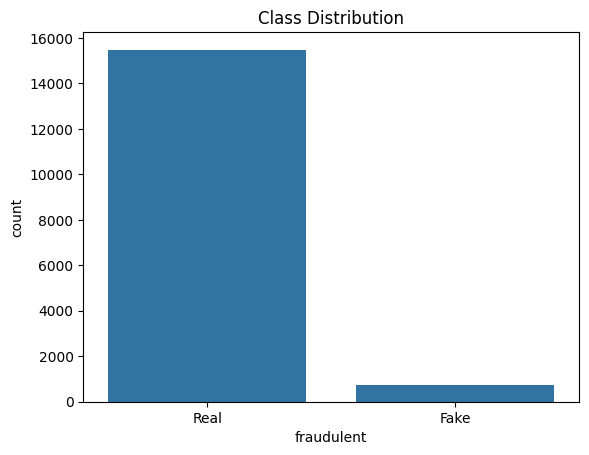

fraudulent
0    0.954321
1    0.045679
Name: proportion, dtype: float64


In [25]:
sns.countplot(x='fraudulent', data=df)
plt.title("Class Distribution")
plt.xticks([0,1], ['Real', 'Fake'])
plt.show()

print(df['fraudulent'].value_counts(normalize=True))

## **Fraud Rate in Binary Features**

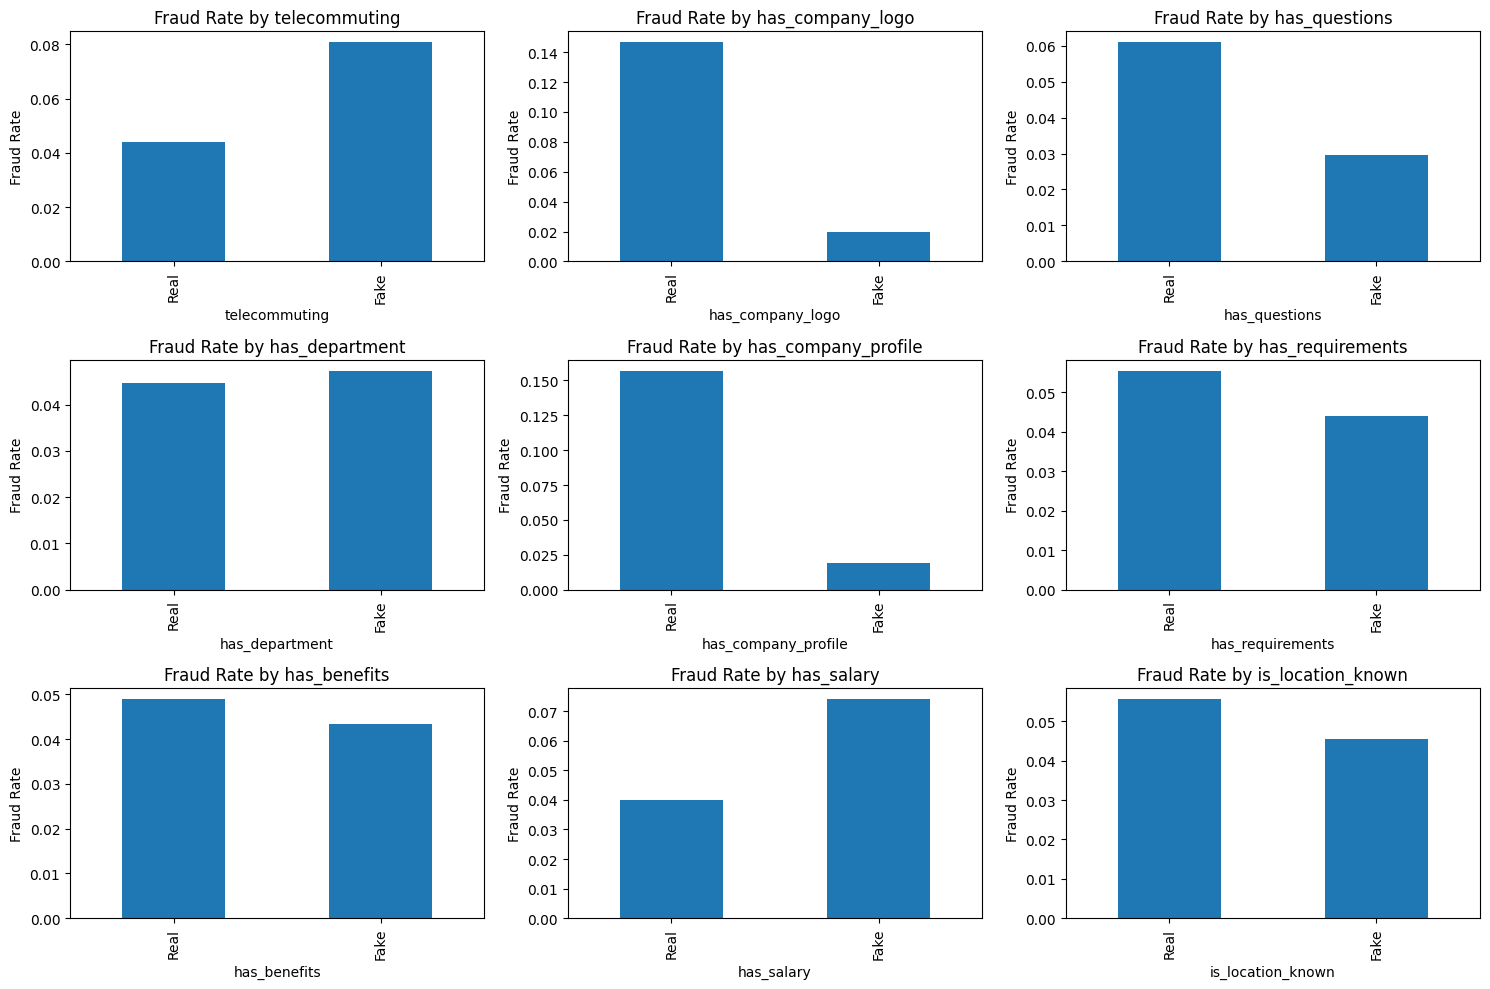

In [26]:
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions',
               'has_department', 'has_company_profile', 'has_requirements',
               'has_benefits', 'has_salary', 'is_location_known']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), binary_cols):
    fraud_rate = df.groupby(col)['fraudulent'].mean()
    fraud_rate.plot(kind='bar', ax=ax, title=f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Real', 'Fake'])
plt.tight_layout()
plt.show()

## **Numeric Features Distributions**

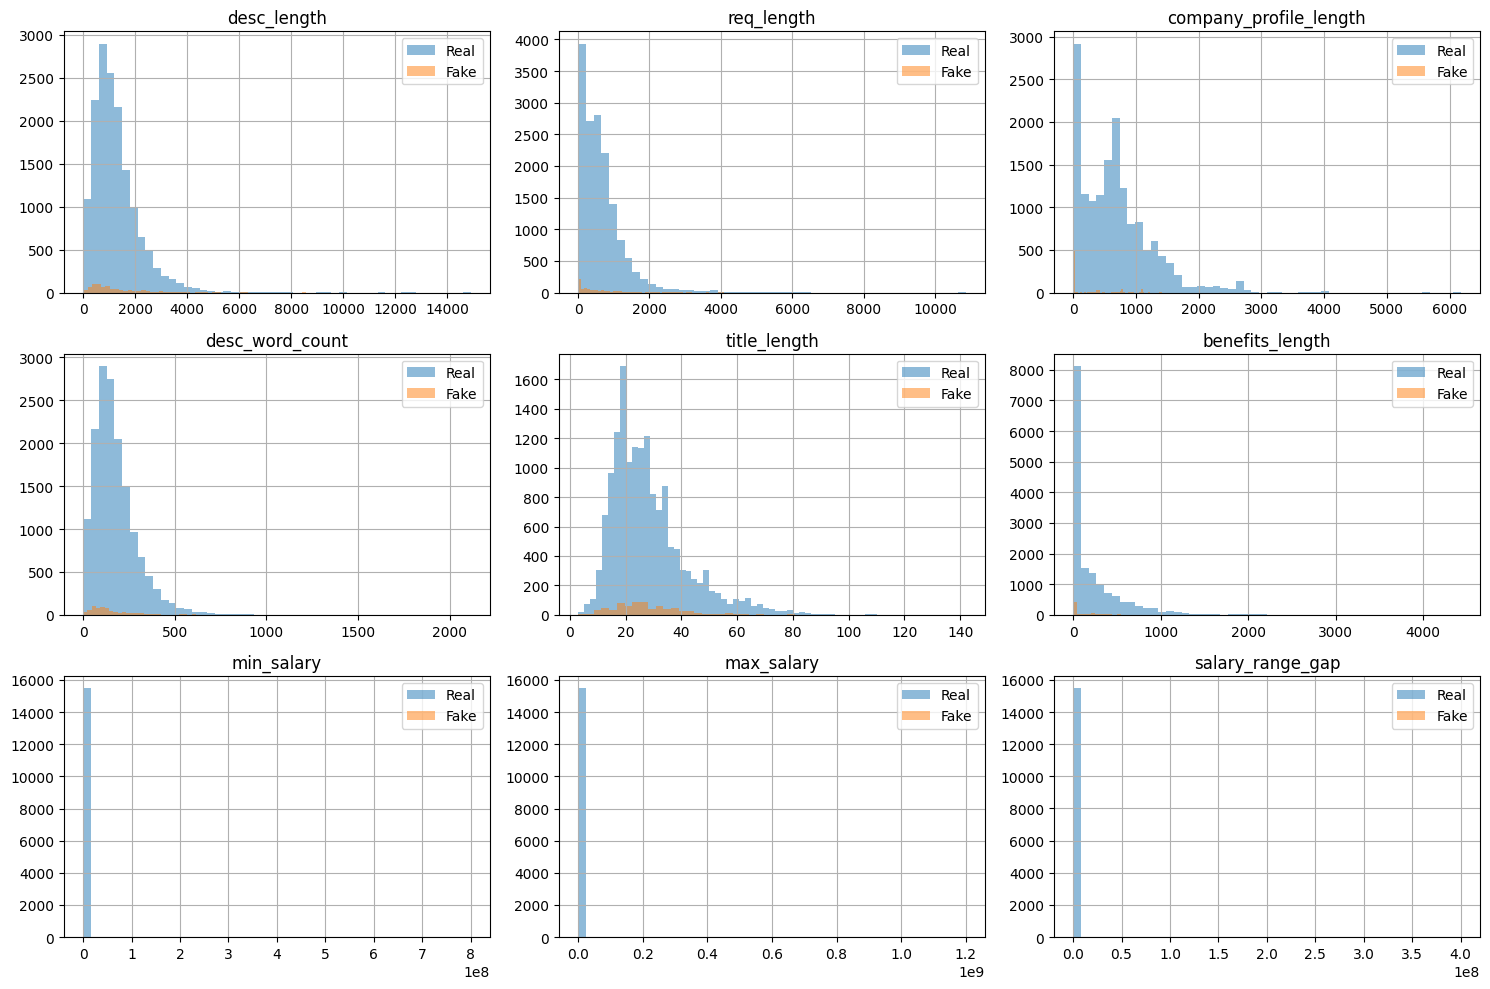

In [27]:
numeric_cols = ['desc_length', 'req_length', 'company_profile_length',
                'desc_word_count', 'title_length', 'benefits_length',
                'min_salary', 'max_salary', 'salary_range_gap']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    df[df['fraudulent']==0][col].hist(ax=ax, alpha=0.5, label='Real', bins=50)
    df[df['fraudulent']==1][col].hist(ax=ax, alpha=0.5, label='Fake', bins=50)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

### **Fraud Rate by `employment_type` and `required_experience`**

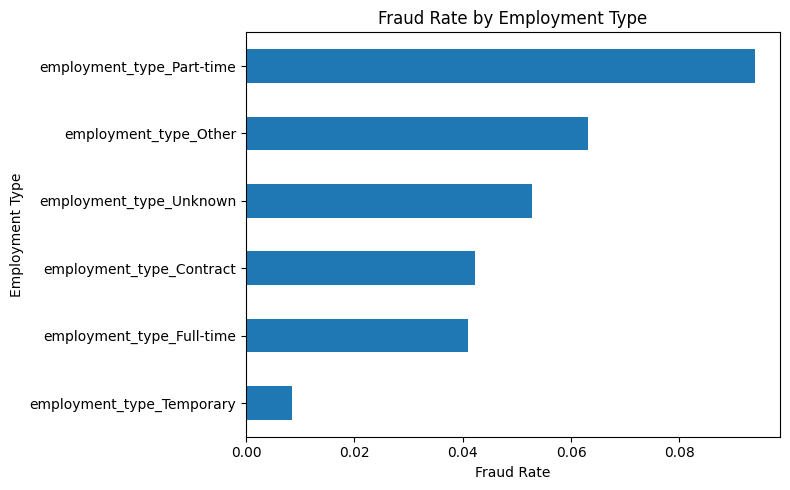

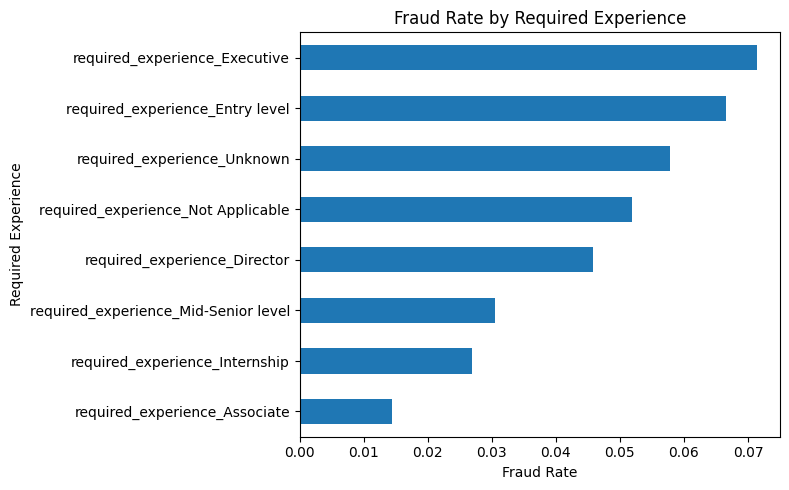

In [28]:
emp_cols = [c for c in df.columns if 'employment_type_' in c]
fraud_by_emp = df[emp_cols].multiply(df['fraudulent'], axis=0).sum() / df[emp_cols].sum()
fraud_by_emp.sort_values().plot(kind='barh', figsize=(8,5), title='Fraud Rate by Employment Type')
plt.xlabel('Fraud Rate')
plt.ylabel('Employment Type')
plt.tight_layout()
plt.show()

exp_cols = [c for c in df.columns if 'required_experience_' in c]
fraud_by_exp = df[exp_cols].multiply(df['fraudulent'], axis=0).sum() / df[exp_cols].sum()
fraud_by_exp.sort_values().plot(kind='barh', figsize=(8,5), title='Fraud Rate by Required Experience')
plt.xlabel('Fraud Rate')
plt.ylabel('Required Experience')
plt.tight_layout()
plt.show()

## **Correlation Analysis**

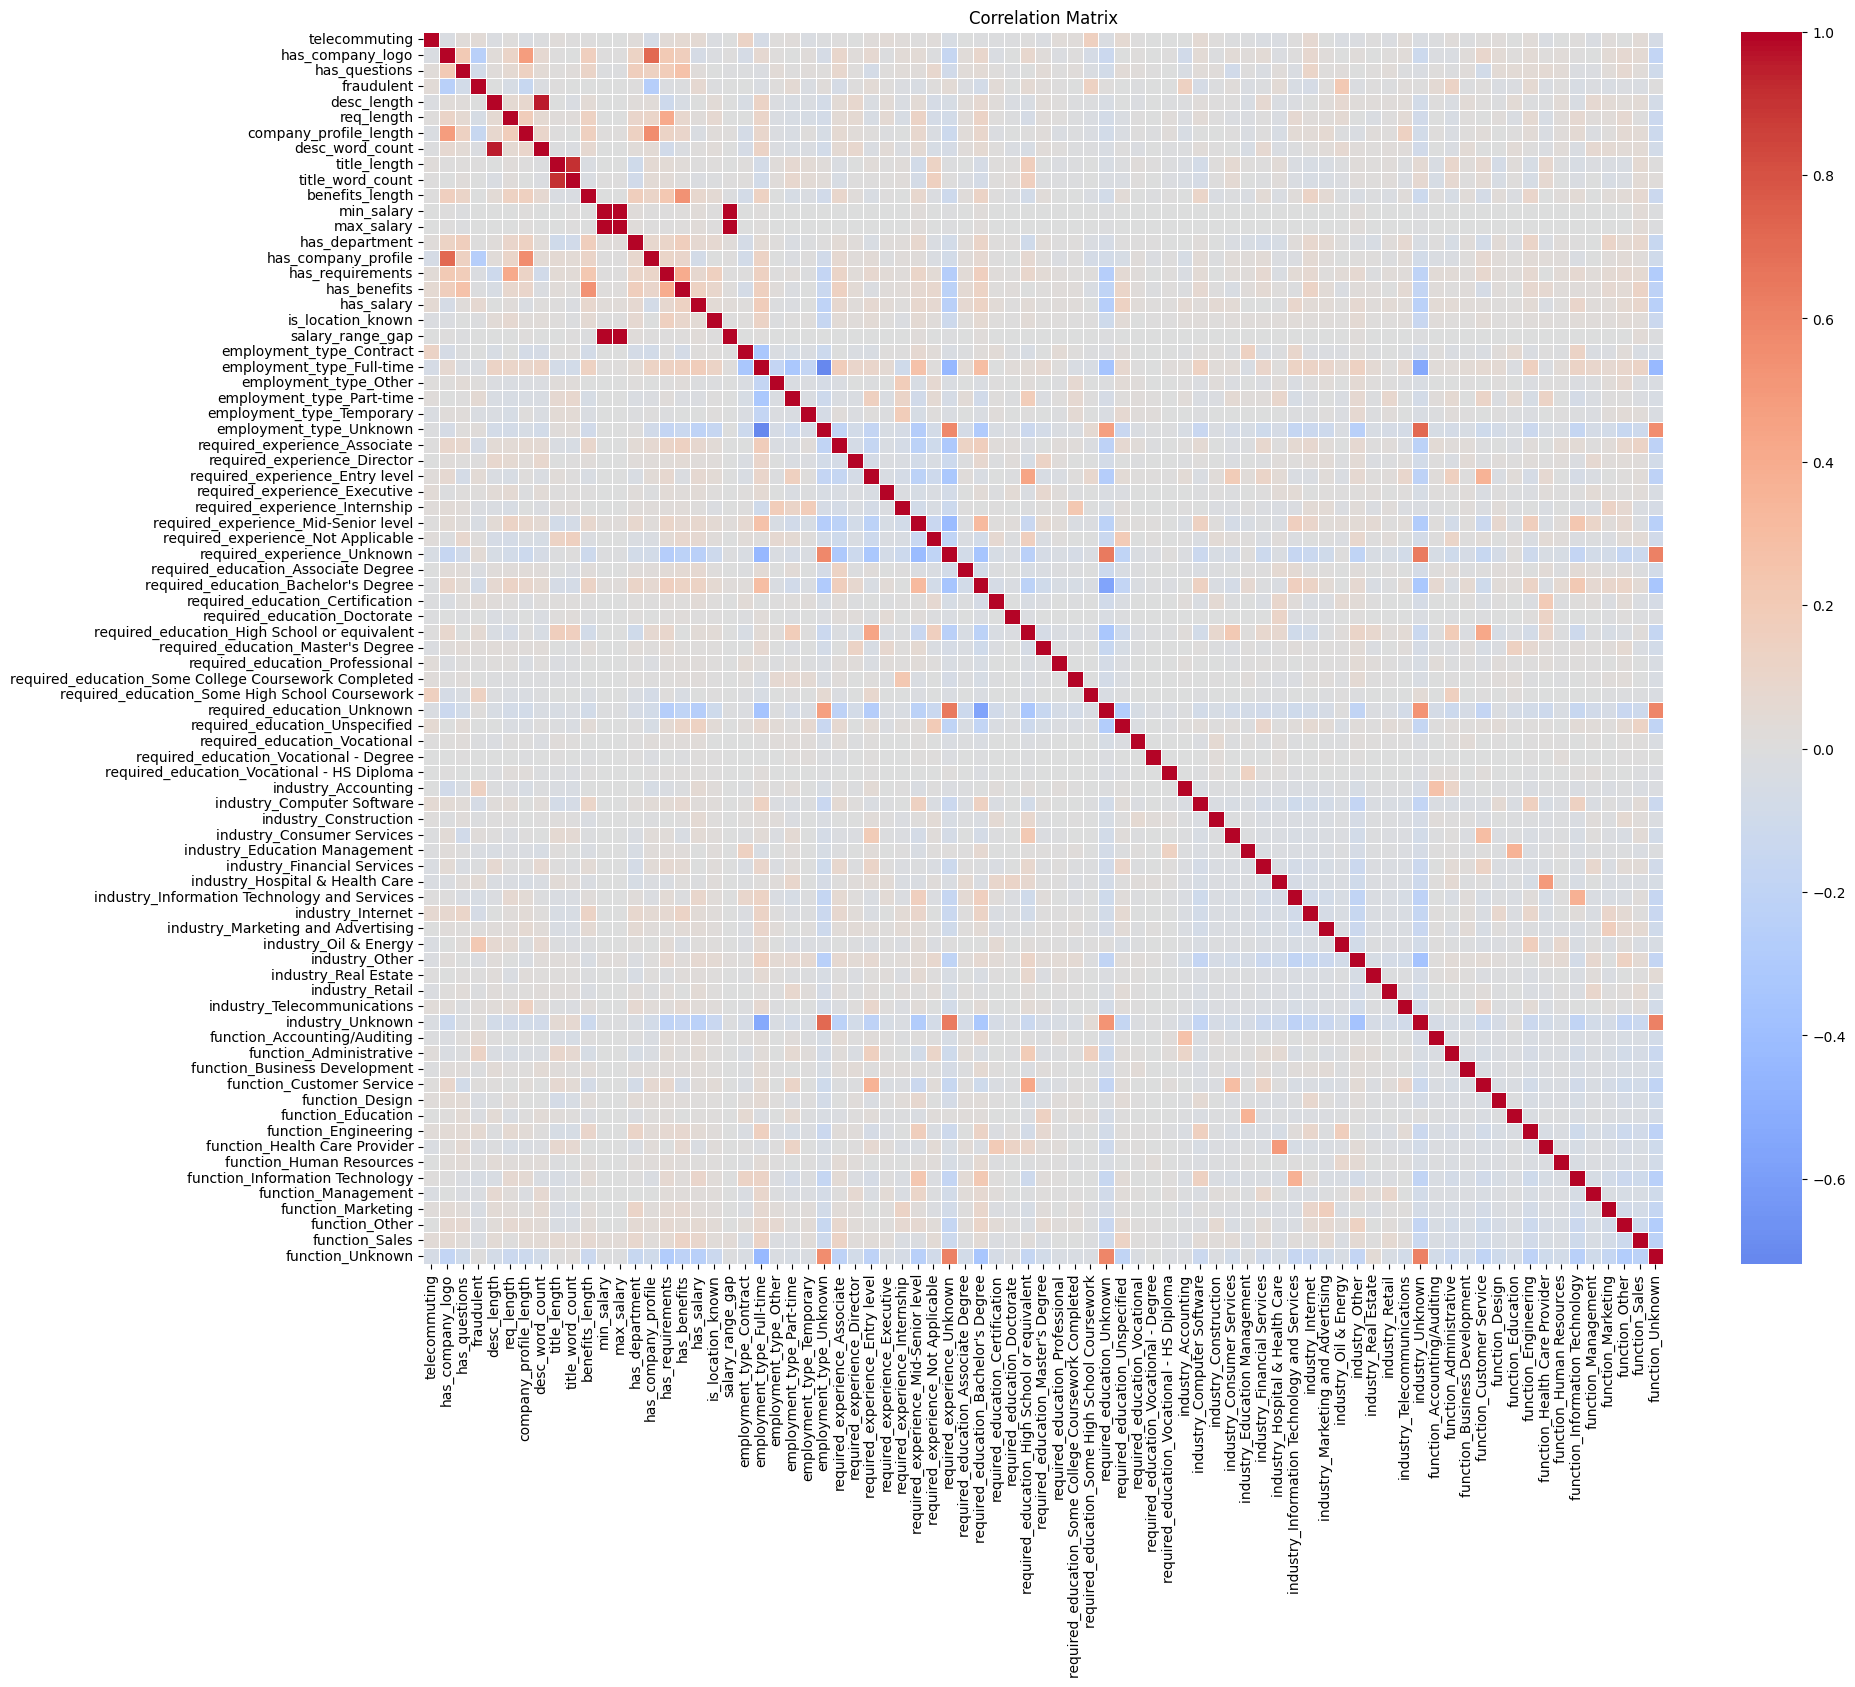


Correlation with 'fraudulent' target variable:
has_company_profile                              -0.260173
has_company_logo                                 -0.244371
company_profile_length                           -0.153502
has_questions                                    -0.075127
required_education_Bachelor's Degree             -0.067729
                                                    ...   
has_salary                                        0.061158
function_Administrative                           0.126426
required_education_Some High School Coursework    0.135929
industry_Accounting                               0.141131
industry_Oil & Energy                             0.221293
Name: fraudulent, Length: 78, dtype: float64


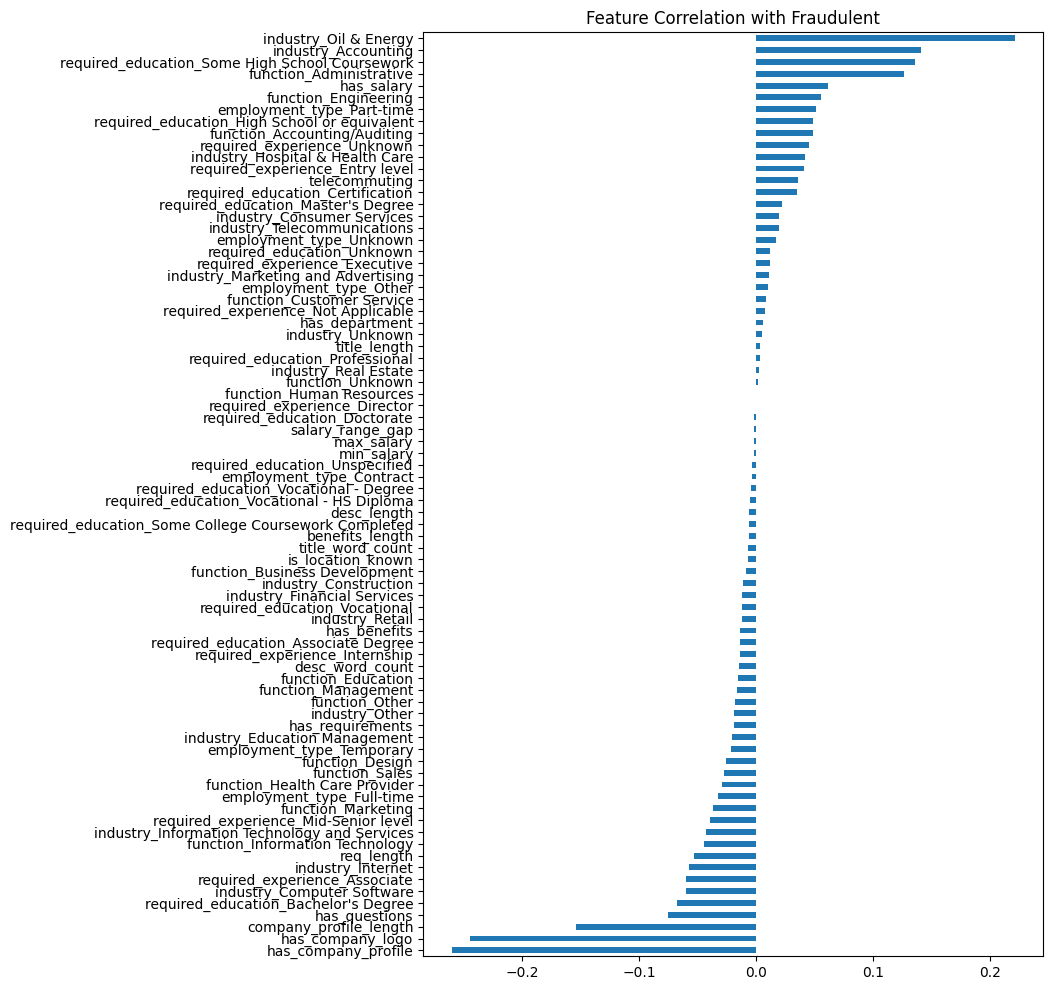

In [29]:
numeric_df = df.drop(columns=['job_text', 'country'], errors='ignore')

plt.figure(figsize=(20, 16))
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# Most important — correlation with target
target_corr = corr['fraudulent'].drop('fraudulent').sort_values()
print("\nCorrelation with 'fraudulent' target variable:")
print(target_corr)

target_corr.plot(kind='barh', figsize=(8, 12), title='Feature Correlation with Fraudulent')
plt.show()

## **Dropping Columns**

These columns are contributing almost nothing, instead of helping they might confuse the model later on while training, so it's safe to drop them right once we have created relevant features from them or extracted important information from them:
- `min_salary`
- `max_salary`
- `salary_range_gap`
- `is_location_known`
- `title_word_count`
- `benefits_length`
- `desc_length`


In [30]:
columns_to_drop = [
    'min_salary',
    'max_salary',
    'salary_range_gap',
    'is_location_known',
    'benefits_length',
    'title_word_count',
    'desc_length'
]

df = df.drop(columns = columns_to_drop, errors = 'ignore')

print(df.columns)

Index(['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent',
       'req_length', 'company_profile_length', 'desc_word_count',
       'title_length', 'has_department', 'has_company_profile',
       'has_requirements', 'has_benefits', 'has_salary', 'job_text',
       'employment_type_Contract', 'employment_type_Full-time',
       'employment_type_Other', 'employment_type_Part-time',
       'employment_type_Temporary', 'employment_type_Unknown',
       'required_experience_Associate', 'required_experience_Director',
       'required_experience_Entry level', 'required_experience_Executive',
       'required_experience_Internship',
       'required_experience_Mid-Senior level',
       'required_experience_Not Applicable', 'required_experience_Unknown',
       'required_education_Associate Degree',
       'required_education_Bachelor's Degree',
       'required_education_Certification', 'required_education_Doctorate',
       'required_education_High School or equivalent',
    

# **MACHINE LEARNING**

### **Imports**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix

import warnings
warnings.filterwarnings('ignore')

### **Verify Class Imbalance**

Class distribution (counts):
fraudulent
0    15481
1      741
Name: count, dtype: int64

Class distribution (percentages):
fraudulent
0    95.43
1     4.57
Name: proportion, dtype: float64


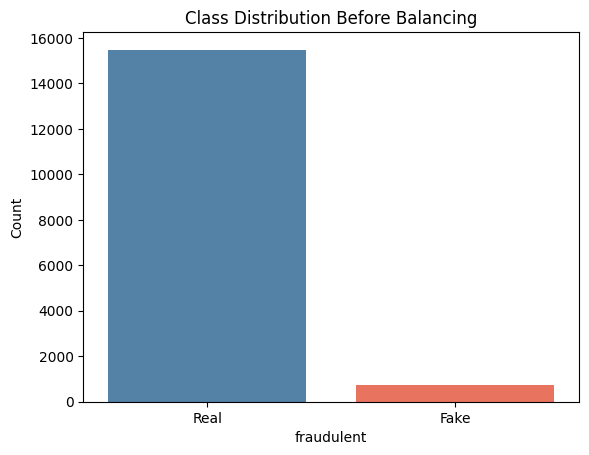

In [32]:
print("Class distribution (counts):")
print(df['fraudulent'].value_counts())

print("\nClass distribution (percentages):")
print(df['fraudulent'].value_counts(normalize=True).mul(100).round(2))

sns.countplot(x='fraudulent', data=df, palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title("Class Distribution Before Balancing")
plt.ylabel("Count")
plt.show()

### **Train-Test Split**

In [33]:
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print(f"\nFraud rate in train : {y_train.mean():.4f}")
print(f"Fraud rate in test  : {y_test.mean():.4f}")

Training set size : 12977
Test set size     : 3245

Fraud rate in train : 0.0457
Fraud rate in test  : 0.0456


`stratify=y` is non-negotiable here. Without it, a random split on a 95/5 dataset could put almost all fraud cases in one split by chance, making your evaluation meaningless. Stratification guarantees the same fraud ratio appears in both train and test. The split is done first — before TF-IDF, before SMOTE — because both of those must only ever see training data.

### **TF-IDF on `job_text`**

In [34]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train['job_text'])
X_test_tfidf  = tfidf.transform(X_test['job_text'])

print(f"TF-IDF train matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF test matrix shape : {X_test_tfidf.shape}")

TF-IDF train matrix shape: (12977, 5000)
TF-IDF test matrix shape : (3245, 5000)


### **Preparing Numeric Features**

In [35]:
numeric_cols = [c for c in X_train.columns if c not in ['job_text', 'country']]

X_train_num = X_train[numeric_cols].fillna(0).astype(float)
X_test_num  = X_test[numeric_cols].fillna(0).astype(float)

scaler = StandardScaler(with_mean=False)
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

print(f"Numeric feature matrix shape: {X_train_num_scaled.shape}")

Numeric feature matrix shape: (12977, 71)


Standard Scaler: Scales the values with mean = 0, std = 1

### **Combine Numeric + TF-IDF**

In [36]:
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_num_scaled)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_num_scaled)])

print(f"Combined train matrix shape: {X_train_combined.shape}")
print(f"Combined test matrix shape : {X_test_combined.shape}")

Combined train matrix shape: (12977, 5071)
Combined test matrix shape : (3245, 5071)


**hstack**: appends columns from the second matrix to the right of the first.
Since **scipy.sparse.hstack** requires both inputs to be sparse. so we use csr_matrix to make *X_train_num_scaled* to a sparse matrix.
**CSR**: Compressed Sparse Row


### **`SMOTE` to handle Class Imbalance**

In [37]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_combined, y_train)

print(f"Before SMOTE — Real: {sum(y_train==0)}, Fake: {sum(y_train==1)}")
print(f"After SMOTE  — Real: {sum(y_train_resampled==0)}, Fake: {sum(y_train_resampled==1)}")

Before SMOTE — Real: 12384, Fake: 593
After SMOTE  — Real: 12384, Fake: 12384


**SMOTE**: Synthetic Minority Oversampling Technique, use k = 5 nearest neigjhbours to oversample the minority class, i.e. fradulent

## **CROSS VALIDATION**

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

numeric_cols_for_cv = [c for c in X_train.columns if c not in ['job_text', 'country']]

preprocessor = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                              stop_words='english', min_df=5, sublinear_tf=True), 'job_text'),
    ('num', StandardScaler(with_mean=False), numeric_cols_for_cv)
])

lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42))
])

X_train_num_raw = X_train[[c for c in X_train.columns if c not in ['job_text', 'country']]].fillna(0).astype(float)


rf_pipeline = ImbPipeline([
    ('num_scaler', StandardScaler(with_mean=False)),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                          random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                               cv=cv, scoring='f1', n_jobs=-1)

rf_cv_scores = cross_val_score(rf_pipeline, X_train_num_raw, y_train,
                               cv=cv, scoring='f1', n_jobs=-1)

print("5-Fold Cross-Validation F1 Scores (Fake class)")
print("-" * 45)
print(f"Logistic Regression : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Random Forest       : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

5-Fold Cross-Validation F1 Scores (Fake class)
---------------------------------------------
Logistic Regression : 0.6084 ± 0.0281
Random Forest       : 0.6815 ± 0.0138


## **Hyperparameter Tuning**

In [39]:
best_C = 1.0
best_penalty = 'l2'

print(f"Parameters selected based on cross-validation results:")
print(f"Best C       : {best_C}")
print(f"Best Penalty : {best_penalty}")

Parameters selected based on cross-validation results:
Best C       : 1.0
Best Penalty : l2


In [40]:
# from sklearn.model_selection import RandomizedSearchCV

# tuning_preprocessor = ColumnTransformer(transformers=[
#     ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2),
#                               stop_words='english', min_df=5, sublinear_tf=True), 'job_text'),
#     ('num', StandardScaler(with_mean=False), numeric_cols_for_cv)
# ])

# tuning_pipeline = ImbPipeline([
#     ('preprocessor', tuning_preprocessor),
#     ('smote', SMOTE(random_state=42, k_neighbors=5)),
#     ('classifier', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
# ])

# param_dist = {
#     'classifier__C': [0.1, 1.0, 10.0],
#     'classifier__penalty': ['l1', 'l2']
# }

# random_search = RandomizedSearchCV(
#     tuning_pipeline,
#     param_distributions=param_dist,
#     n_iter=4,
#     cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
#     scoring='f1',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# random_search.fit(X_train, y_train)

# print(f"Best Parameters : {random_search.best_params_}")
# print(f"Best CV F1      : {random_search.best_score_:.4f}")

# best_C = random_search.best_params_['classifier__C']
# best_penalty = random_search.best_params_['classifier__penalty']

## **LOGISTIC REGRESSION**

In [41]:
lr_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    max_iter=1000,
    solver='saga',
    random_state=42
)

lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test_combined)
y_prob_lr = lr_model.predict_proba(X_test_combined)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 50)
print(f"Best C used       : {best_C}")
print(f"Best Penalty used : {best_penalty}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Real', 'Fake']))

LOGISTIC REGRESSION — EVALUATION
Best C used       : 1.0
Best Penalty used : l2
Accuracy  : 0.9556
Precision : 0.5076
Recall    : 0.9054
F1 Score  : 0.6505

Detailed Report:
              precision    recall  f1-score   support

        Real       1.00      0.96      0.98      3097
        Fake       0.51      0.91      0.65       148

    accuracy                           0.96      3245
   macro avg       0.75      0.93      0.81      3245
weighted avg       0.97      0.96      0.96      3245



### **Logistic Regression - Confusion Matrix**

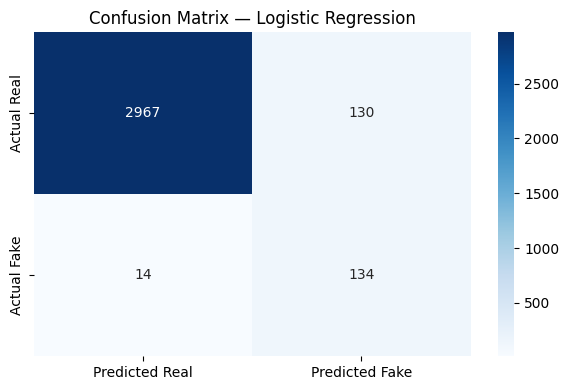


True Negatives  (Real → Real) : 2967
False Positives (Real → Fake) : 130
False Negatives (Fake → Real) : 14  ← missed fraud
True Positives  (Fake → Fake) : 134  ← caught fraud


In [42]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"\nTrue Negatives  (Real → Real) : {tn}")
print(f"False Positives (Real → Fake) : {fp}")
print(f"False Negatives (Fake → Real) : {fn}  ← missed fraud")
print(f"True Positives  (Fake → Fake) : {tp}  ← caught fraud")

### **Threshold Tuning - Logistic Regression**

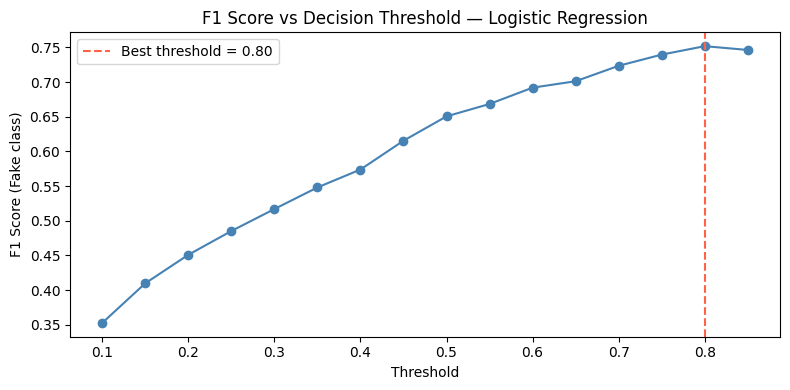


Best threshold : 0.80
Best F1 Score  : 0.7517

After threshold tuning:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3097
        Fake       0.77      0.74      0.75       148

    accuracy                           0.98      3245
   macro avg       0.88      0.86      0.87      3245
weighted avg       0.98      0.98      0.98      3245



In [43]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores_thresh = [f1_score(y_test, (y_prob_lr >= t).astype(int)) for t in thresholds]

best_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores_thresh[best_idx]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores_thresh, marker='o', color='steelblue')
plt.axvline(x=best_threshold, color='tomato', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Fake class)")
plt.title("F1 Score vs Decision Threshold — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

y_pred_lr_tuned = (y_prob_lr >= best_threshold).astype(int)
print("\nAfter threshold tuning:")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Real', 'Fake']))

## **RANDOM FOREST**


In [44]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

X_train_num_smote, y_train_num_smote = smote.fit_resample(
    csr_matrix(X_train_num_scaled), y_train
)

rf_model.fit(X_train_num_smote, y_train_num_smote)

y_pred_rf = rf_model.predict(X_test_num_scaled)
y_prob_rf = rf_model.predict_proba(X_test_num_scaled)[:, 1]

print("=" * 50)
print("RANDOM FOREST — EVALUATION (Numeric Features)")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Real', 'Fake']))

RANDOM FOREST — EVALUATION (Numeric Features)
Accuracy  : 0.9572
Precision : 0.5228
Recall    : 0.6959
F1 Score  : 0.5971

Detailed Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      3097
        Fake       0.52      0.70      0.60       148

    accuracy                           0.96      3245
   macro avg       0.75      0.83      0.79      3245
weighted avg       0.96      0.96      0.96      3245



### **Random Forest - Confusion Matrix**

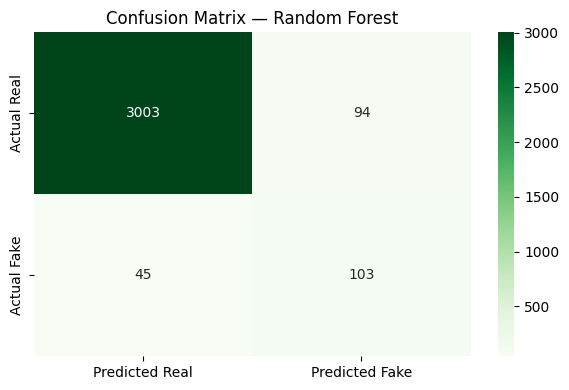


True Negatives  : 3003
False Positives : 94
False Negatives : 45  ← missed fraud
True Positives  : 103  ← caught fraud


In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\nTrue Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}  ← missed fraud")
print(f"True Positives  : {tp}  ← caught fraud")

### **Feature Importance from RF**

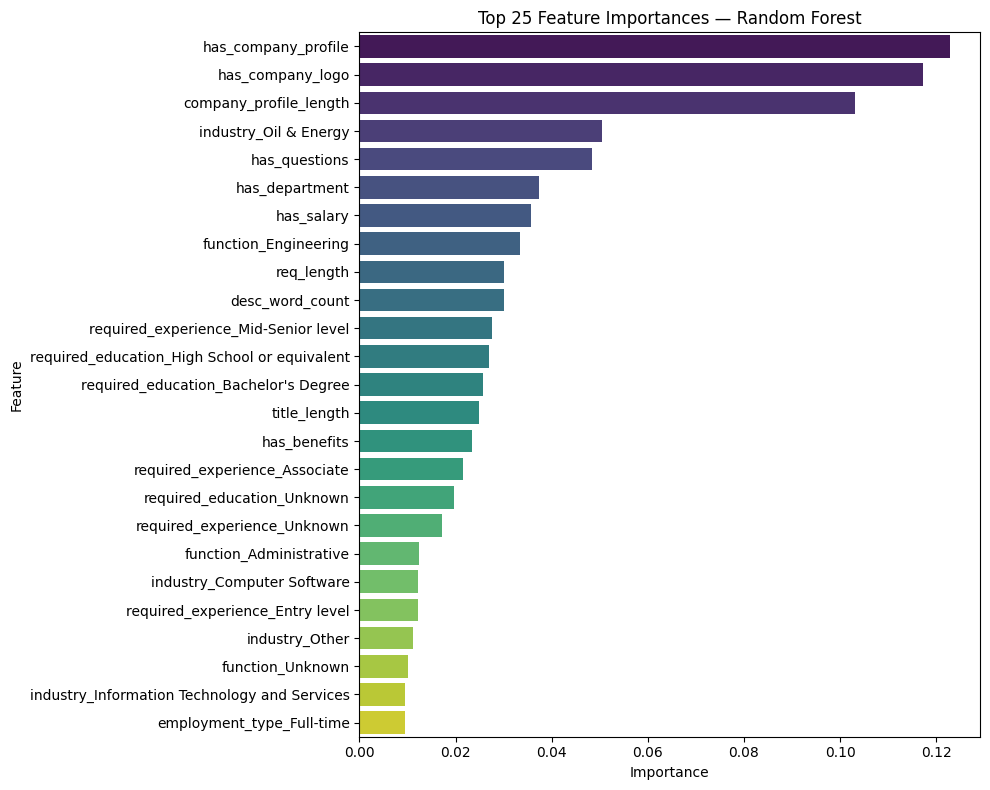

                                     Feature  Importance
                         has_company_profile    0.122956
                            has_company_logo    0.117233
                      company_profile_length    0.103191
                       industry_Oil & Energy    0.050407
                               has_questions    0.048364
                              has_department    0.037370
                                  has_salary    0.035626
                        function_Engineering    0.033319
                                  req_length    0.030168
                             desc_word_count    0.030153
        required_experience_Mid-Senior level    0.027513
required_education_High School or equivalent    0.026927
        required_education_Bachelor's Degree    0.025636
                                title_length    0.024891
                                has_benefits    0.023407
               required_experience_Associate    0.021638
                  required_educ

In [46]:
feature_names = numeric_cols
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(25)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Top 25 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

print(feat_imp_df.to_string(index=False))

## **Side-by-side Model Comparison**

COMPLETE MODEL COMPARISON — ALL METRICS
                                              Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Model                                                                                               
Logistic Regression (default threshold 0.50)    0.9556     0.5076  0.9054    0.6505   0.9775  0.8212
Logistic Regression (tuned threshold = 0.80)    0.9778     0.7676  0.7365    0.7517   0.9775  0.8212
Random Forest (numeric features only)           0.9572     0.5228  0.6959    0.5971   0.9619  0.7233


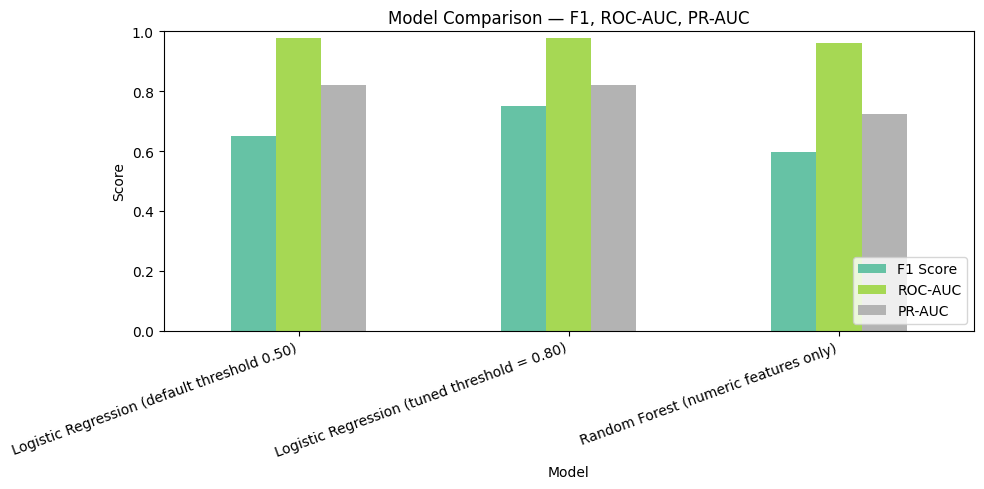

In [47]:
results = {
    'Model': [
        'Logistic Regression (default threshold 0.50)',
        f'Logistic Regression (tuned threshold = {best_threshold:.2f})',
        'Random Forest (numeric features only)'
    ],
    'Accuracy' : [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr_tuned),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall'   : [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr_tuned),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score' : [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_tuned),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC'  : [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'PR-AUC'   : [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 70)
print("COMPLETE MODEL COMPARISON — ALL METRICS")
print("=" * 70)
print(results_df.round(4).to_string())

# Bar chart — F1, ROC-AUC, PR-AUC
results_df[['F1 Score', 'ROC-AUC', 'PR-AUC']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), colormap='Set2'
)
plt.title("Model Comparison — F1, ROC-AUC, PR-AUC")
plt.xticks(rotation=20, ha='right')
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **ROC-AUC** and **PR-AUC**

Logistic Regression  |  ROC-AUC = 0.9775  |  PR-AUC (AP) = 0.8212
Random Forest        |  ROC-AUC = 0.9619  |  PR-AUC (AP) = 0.7233
Random baseline      |  ROC-AUC = 0.5000       |  PR-AUC (AP) = 0.0456


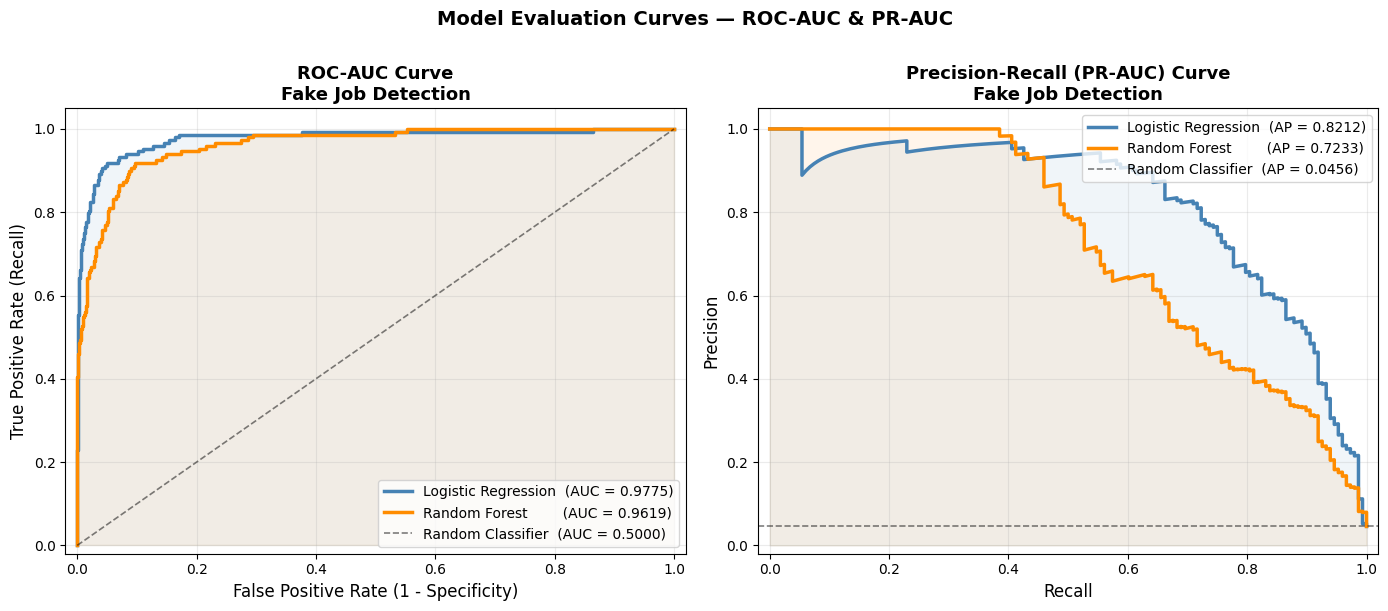


ROC-AUC Interpretation:
  LR  AUC=0.9775 — correctly ranks a random Fake above a random Real 97.8% of the time
  RF  AUC=0.9619 — lower because RF uses only 71 structured features vs 5,071 for LR

PR-AUC Interpretation:
  Fraud rate (baseline AP) = 0.0456
  LR  AP=0.8212 — 18.0x above random baseline on the fraud class
  RF  AP=0.7233 — 15.9x above random baseline on the fraud class

PR-AUC is the stricter metric on this imbalanced dataset.
ROC-AUC can appear inflated when negatives heavily outnumber positives.
Both curves together confirm the model's learned discrimination is real.


In [48]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Computing curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

prec_lr_curve, rec_lr_curve, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf_curve, rec_rf_curve, _ = precision_recall_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
ap_lr  = average_precision_score(y_test, y_prob_lr)
ap_rf  = average_precision_score(y_test, y_prob_rf)
baseline_pr = y_test.mean()   # random classifier PR baseline = fraud rate

print(f"Logistic Regression  |  ROC-AUC = {auc_lr:.4f}  |  PR-AUC (AP) = {ap_lr:.4f}")
print(f"Random Forest        |  ROC-AUC = {auc_rf:.4f}  |  PR-AUC (AP) = {ap_rf:.4f}")
print(f"Random baseline      |  ROC-AUC = 0.5000       |  PR-AUC (AP) = {baseline_pr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =============
# ROC Curve
# =============

ax = axes[0]
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2.5,
        label=f'Logistic Regression  (AUC = {auc_lr:.4f})')
ax.plot(fpr_rf, tpr_rf, color='darkorange', lw=2.5,
        label=f'Random Forest        (AUC = {auc_rf:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5,
        label='Random Classifier  (AUC = 0.5000)')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='steelblue')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='darkorange')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC-AUC Curve\nFake Job Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
ax.grid(alpha=0.25)


# =============
# PR Curve
# =============

ax2 = axes[1]
ax2.plot(rec_lr_curve, prec_lr_curve, color='steelblue', lw=2.5,
         label=f'Logistic Regression  (AP = {ap_lr:.4f})')
ax2.plot(rec_rf_curve, prec_rf_curve, color='darkorange', lw=2.5,
         label=f'Random Forest        (AP = {ap_rf:.4f})')
ax2.axhline(y=baseline_pr, color='k', linestyle='--', lw=1.2, alpha=0.5,
            label=f'Random Classifier  (AP = {baseline_pr:.4f})')
ax2.fill_between(rec_lr_curve, prec_lr_curve, alpha=0.08, color='steelblue')
ax2.fill_between(rec_rf_curve, prec_rf_curve, alpha=0.08, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall (PR-AUC) Curve\nFake Job Detection', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim([-0.02, 1.02]); ax2.set_ylim([-0.02, 1.05])
ax2.grid(alpha=0.25)

plt.suptitle('Model Evaluation Curves — ROC-AUC & PR-AUC', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nROC-AUC Interpretation:")
print(f"  LR  AUC={auc_lr:.4f} — correctly ranks a random Fake above a random Real {auc_lr*100:.1f}% of the time")
print(f"  RF  AUC={auc_rf:.4f} — lower because RF uses only 71 structured features vs 5,071 for LR")
print("\nPR-AUC Interpretation:")
print(f"  Fraud rate (baseline AP) = {baseline_pr:.4f}")
print(f"  LR  AP={ap_lr:.4f} — {ap_lr/baseline_pr:.1f}x above random baseline on the fraud class")
print(f"  RF  AP={ap_rf:.4f} — {ap_rf/baseline_pr:.1f}x above random baseline on the fraud class")
print("\nPR-AUC is the stricter metric on this imbalanced dataset.")
print("ROC-AUC can appear inflated when negatives heavily outnumber positives.")
print("Both curves together confirm the model's learned discrimination is real.")